---
title: Reading the SCC decomposition tree map
---

`Graph.plot_scc_decomposition()` visualises the strongly-connected-component (SCC) condensation of a phasic graph as a level-wise treemap. This notebook walks through four worked examples — a hand-built tiny cyclic graph, a coalescent, a two-locus ARG, and a spatial migration model — to explain what the plot shows and how to read it.

The plot is the practical tool for deciding whether `phasic.configure(parallel_elimination=True)` is going to help on a given model. Wide rows = good parallelism potential; rows with a single tile = elimination bottlenecks; many small SCCs = the hierarchical composer can split the O(n³) elimination across threads.

## What the plot shows

A few facts that are easy to get wrong:

1. **The plot is a partition, not a recursive subdivision.** Every vertex belongs to exactly one SCC. The treemap groups SCCs by their level in the condensation. The widths in one row are unrelated to the widths in another except that the **absolute scale is shared**: 1 horizontal unit = 1 vertex, in every row.
2. **Total area is conserved.** Sum of all tile widths across all rows = total number of vertices in the graph. A wider row simply means that level holds more vertices, not that something has been "subdivided into more pieces".
3. **The vertical axis is the condensation level, not time per se.** We draw the source-side (start vertex) at the top and the sink-side (absorbing state) at the bottom so that for a typical forward-in-time chain the arrow of time points downward.
4. **Tile width = vertex count of one SCC.** The label `#i, Nv` inside a wide-enough tile reports the SCC index `i` and its vertex count `N`. The row label on the left, e.g. `L5 (23)`, reports the level number and the count of parallel-eliminable SCCs at that level.

In [1]:
from phasic import (
    Graph, Property, StateIndexer, with_ipv, 
    cache, configure, clear_caches
)
from phasic.distributed_scc import compute_scc_levels
from vscodenb import set_vscode_theme
set_vscode_theme()


def summarise(g):
    """Print the (n_sccs, n_levels, row widths, sum) tuple
    that the plot encodes graphically."""
    scc = g.scc_decomposition()
    levels = compute_scc_levels(scc)
    widths = [sum(scc.scc_at(i).size() for i in lvl) for lvl in levels]
    total = sum(widths)
    print(f"  vertices total:      {g.vertices_length()}")
    print(f"  SCCs total:          {len(scc)}")
    print(f"  levels:              {len(levels)}")
    print(f"  row widths (top->bottom): {list(reversed(widths))}")
    print(f"  sum of row widths:   {total}  (== total vertex count)")
    print(f"  widest row:          {max(widths)} vertices, "
          f"{max(map(len, levels))} parallel SCCs")

## Example 1: A tiny graph with one cycle

The smallest interesting case: 5 vertices, with vertices 1→2→3 forming a back-loop (vertex 3 has a chance of falling back to vertex 1). Vertex 0 is the start; vertex 4 is the absorbing sink.

Decomposition: `{0}`, `{1, 2, 3}`, `{4}` — three SCCs, the middle one is cyclic (size 3), the other two are singletons. You can verify the row widths by counting on your fingers.

In [2]:
g_tiny = Graph(1)
v0 = g_tiny.starting_vertex()
v1 = g_tiny.find_or_create_vertex([1])
v2 = g_tiny.find_or_create_vertex([2])
v3 = g_tiny.find_or_create_vertex([3])
v4 = g_tiny.find_or_create_vertex([4])  # absorbing
v0.add_edge(v1, 1.0)
v1.add_edge(v2, 1.0)
v2.add_edge(v3, 1.0)
v3.add_edge(v1, 0.5)   # back-edge: closes the cycle {1, 2, 3}
v3.add_edge(v4, 0.5)   # exit edge to the sink

summarise(g_tiny)

  vertices total:      5
  SCCs total:          3
  levels:              3
  row widths (top->bottom): [1, 3, 1]
  sum of row widths:   5  (== total vertex count)
  widest row:          3 vertices, 1 parallel SCCs


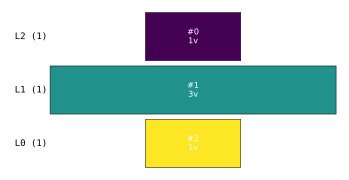

In [3]:
g_tiny.plot_scc_decomp(figsize=(6, 3));

Three rows: top tile (source, 1v) → middle tile (the cyclic SCC, 3v) → bottom tile (sink, 1v). The middle tile is three times as wide as the top and bottom tiles, because it contains three vertices.

If this graph had no back-edge — i.e. if vertex 3 only ever moved forward — all three SCCs would be singletons and the plot would have five rows of size 1 each. The cycle is precisely what merges {1,2,3} into a single SCC.

## Example 2: A coalescent (no cycles)

The standard coalescent is a strictly forward-in-time process: every transition reduces `state.sum()` by one. There are no cycles, so every vertex is its own SCC and the condensation is just the original graph relabelled.

The "diamond" shape of the treemap reflects the **state-space size profile**: only one configuration with all lineages active (top), many configurations as lineages merge into intermediate-size combinations (middle), one configuration with everything coalesced (bottom). We use `nr_samples = 10` here so the diamond is visible — at 4 samples the graph has only 6 vertices and the shape is degenerate.

In [4]:
@with_ipv([10, 0, 0, 0, 0, 0, 0, 0, 0, 0])
def coalescent10(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append((new, [state[i] * (state[j] - same) / (1 + same)]))
    return transitions

g_coal = Graph(coalescent10)
g_coal.update_weights([2])
summarise(g_coal)

  vertices total:      43
  SCCs total:          43
  levels:              11
  row widths (top->bottom): [1, 1, 1, 2, 3, 5, 7, 9, 8, 5, 1]
  sum of row widths:   43  (== total vertex count)
  widest row:          9 vertices, 9 parallel SCCs


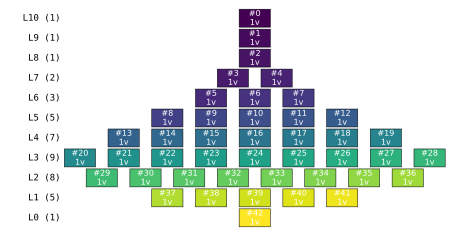

In [5]:
g_coal.plot_scc_decomp(figsize=(8, 4));

Every row has all-singleton tiles (each labelled `1v`). The widest row is at an intermediate level — not because vertices have been "split", but because the state space itself is fattest there.

**Implication for `parallel_elimination=True`**: the SCC composer breaks the elimination into per-SCC pieces, but here every SCC is a single vertex, so per-SCC elimination is trivial. The composer doesn't speed things up, and the disk-cache overhead per SCC may even hurt. For monotone models like the coalescent, leave `parallel_elimination=False` (the default).

## Example 3: A two-locus ARG (recombination = cycles)

The ancestral recombination graph (ARG) on two loci is the coalescent's cyclic cousin. Recombination splits one lineage into two, so the lineage count can *go up* as well as down. That introduces real cycles in the state-space graph: the same configuration of `(loc1, loc2)` lineage counts can be reached by both coalescing and recombining.

The result is many small cyclic SCCs at intermediate levels — exactly the structure the hierarchical SCC composer is designed for.

In [6]:
nr_samples = 6
indexer = StateIndexer(descendants=[
    Property('loc1', max_value=nr_samples),
    Property('loc2', max_value=nr_samples),
])
initial = [0] * indexer.state_length
initial[indexer.props_to_index(loc1=1, loc2=1)] = nr_samples


def two_locus_arg(state, indexer=None):
    transitions = []
    if state.sum() <= 1:
        return transitions
    for i in range(indexer.state_length):
        if state[i] == 0:
            continue
        pi = indexer.index_to_props(i)
        # Coalescence
        for j in range(i, indexer.state_length):
            if state[j] == 0:
                continue
            pj = indexer.index_to_props(j)
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            loc1 = pi.descendants.loc1 + pj.descendants.loc1
            loc2 = pi.descendants.loc2 + pj.descendants.loc2
            if loc1 <= nr_samples and loc2 <= nr_samples:
                child[indexer.props_to_index(loc1=loc1, loc2=loc2)] += 1
                transitions.append([child,
                                    [state[i] * (state[j] - same) / (1 + same), 0]])
        # Recombination — this is what creates cycles
        if state[i] > 0 and pi.descendants.loc1 > 0 and pi.descendants.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.props_to_index(loc1=pi.descendants.loc1, loc2=0)] += 1
            child[indexer.props_to_index(loc1=0, loc2=pi.descendants.loc2)] += 1
            transitions.append([child, [0, 1.0]])
    return transitions


g_arg = Graph(two_locus_arg, ipv=initial, indexer=indexer)
g_arg.update_weights([1, 0.7])
summarise(g_arg)

  vertices total:      1044
  SCCs total:          123
  levels:              13
  row widths (top->bottom): [1, 7, 20, 56, 114, 185, 224, 212, 142, 65, 16, 1, 1]
  sum of row widths:   1044  (== total vertex count)
  widest row:          224 vertices, 23 parallel SCCs


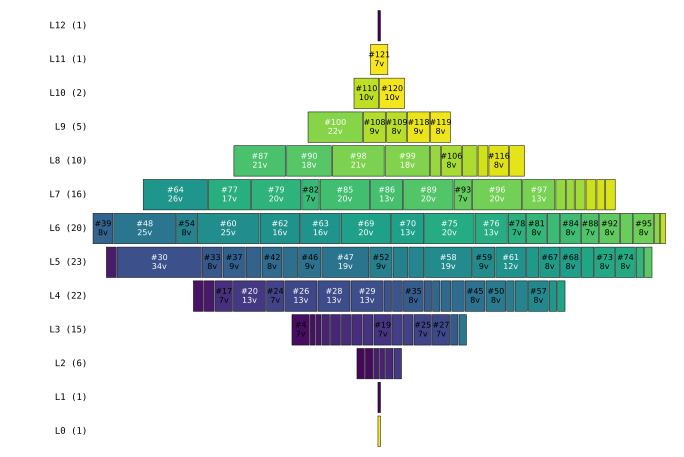

In [7]:
g_arg.plot_scc_decomp(figsize=(12, 8));

Now the tiles inside each row are clearly multi-vertex (e.g. `34v`, `25v`, `21v`). The wide bands in the middle of the diamond — L5 with 23 parallel SCCs, L6 with 20 — are where most of the elimination work lives, and they are highly parallelisable.

With `parallel_elimination=True`, each of the ~120 SCCs is small enough that its O(k³) elimination is cheap, and there are many siblings per level for OpenMP to fan out across. The bottleneck rows L0, L1, L11, L12 (single 1-vertex SCCs) cost essentially nothing.

In [8]:
# Predict the speedup ceiling from the plot:
# total compute time scales with sum(k^3) over SCCs.
# Sequential = sum(k^3); parallel = sum over levels of max(k^3 within level).
# (This ignores composition overhead and assumes infinite threads.)
scc = g_arg.scc_decomposition()
sizes = [scc.scc_at(i).size() for i in range(len(scc))]
levels = compute_scc_levels(scc)

seq_cost = sum(k ** 3 for k in sizes)
par_cost = sum(max(scc.scc_at(i).size() ** 3 for i in lvl) for lvl in levels)
print(f"sequential ~cost:       {seq_cost:,}")
print(f"parallel (max threads): {par_cost:,}")
print(f"theoretical speedup:    {seq_cost / par_cost:.1f}x")

sequential ~cost:       247,122
parallel (max threads): 96,327
theoretical speedup:    2.6x


## Example 4: A migration chain with coalescence

Spatial-style models combine a "where" axis (which cell each lineage occupies) with a "when" axis (how many lineages remain). Within one lineage-count slice, lineages migrate between neighbouring cells — that's cyclic. Across slices, lineages coalesce — that's acyclic. The result is many SCCs (the migration cycles) stacked along an outer DAG (the coalescence levels).

We use a 1D chain of cells with 2 lineages so the example is small and easy to inspect; the principle is the same on a 2D hex grid or a real geographic region.

In [9]:
# 1D chain of 4 cells, 2 lineages. State = list of per-cell
# lineage counts. Migration: a lineage moves between adjacent
# cells. Coalescence: if two lineages share a cell, they merge.
N_CELLS = 4

def migration_chain(state):
    transitions = []
    for i, k in enumerate(state):
        if k == 0:
            continue
        # Migration left
        if i > 0:
            child = state.copy()
            child[i] -= 1
            child[i - 1] += 1
            transitions.append((child, 1.0 * k))
        # Migration right
        if i < N_CELLS - 1:
            child = state.copy()
            child[i] -= 1
            child[i + 1] += 1
            transitions.append((child, 1.0 * k))
        # Coalescence (only if cell has >= 2 lineages)
        if k >= 2:
            child = state.copy()
            child[i] -= 1
            transitions.append((child, 0.5 * k * (k - 1) / 2))
    return transitions

# Start: two lineages, one in cell 0 and one in cell 3.
ipv = [1, 0, 0, 1]
g_mig = Graph(migration_chain, ipv=ipv)
summarise(g_mig)

  vertices total:      15
  SCCs total:          3
  levels:              3
  row widths (top->bottom): [1, 10, 4]
  sum of row widths:   15  (== total vertex count)
  widest row:          10 vertices, 1 parallel SCCs


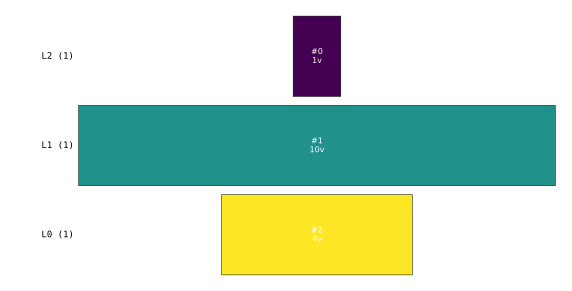

In [10]:
g_mig.plot_scc_decomp(figsize=(10, 5));

The shape is qualitatively different from the ARG diamond: instead of fanning out into many parallel singletons, the migration cycles fuse all the 2-lineage states into one large SCC, then all the 1-lineage states into another. The condensation collapses to a short chain of fat SCCs.

**Implication for `parallel_elimination=True`**: less helpful here than for the ARG, because the rows are narrow (often a single large SCC). Parallelism per level is limited; you can't fan out across siblings if there are no siblings. The hierarchical composer can still help via cross-graph reuse (a migration sub-pattern recurring across different lineage counts), but you won't see the dramatic per-level speedup the ARG enjoys. Profile both ways with `phasic.cache.scc_compose_stats()` to decide.

## Example 5: Coalescent with selection

In [11]:
from phasic import (
    Graph, StateIndexer, Property, SparseObservations, ExpStepSize,
    GaussPrior, LogGaussPrior, BetaPrior, HalfCauchyPrior, Adamelia, dense_to_sparse,
)
import numpy as np
from itertools import combinations_with_replacement
from functools import partial
all_pairs = partial(combinations_with_replacement, r=2)
from scipy.stats import binom
from scipy.stats import beta

def coalescent_with_derived(state, indexer=None, N=None, s=0):
    transitions = []

    # callback params are always float
    N = int(N)

    # derived and total live lineages
    n_anc, n_der = 0, 0
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            n_der += state[i]
        else:
            n_anc += state[i]
    n_live = n_der + n_anc

    if n_live == 1:
        # absorbing state
        return []

    # pop derived freq
    freq = int(state[indexer.derived_freq])

    for i, j in all_pairs(range(indexer.lineages.state_length)):

        # props of lineage types at index i and j
        pi = indexer.lineages.i2p(i)
        pj = indexer.lineages.i2p(j)

        # both either anc or der
        same_ancestry = bool(pi.is_derived) == bool(pj.is_derived) and freq > 0

        # only coalesce derived and ancestral if derived is lost from population (implies the derived is now ancestral too)
        if not same_ancestry and freq > 0:
            continue

        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        is_derived = pi.is_derived if same_ancestry else 0 # can only be 0 if this is the final coalescence
        k = indexer.lineages.p2i(descendants=pi.descendants+pj.descendants, is_derived=is_derived)
        new[k] += 1

        pair_count = state[i] * (state[j] - same) / (1 + same)

        if pi.is_derived and pj.is_derived:
            allele_N = freq
        else:
            allele_N = N

        coef = [pair_count * (N/allele_N), 0, 0]
        transitions.append([new, coef])

    # transitions to sister states with other derived population frequencies
    if n_live > 1 and freq > 0:

        # loop other freqs
        for f in range(N):

            # no self loops
            if f == freq:
                continue

            # der freq an only go to zero when a single der lineage remains
            if n_der > 1 and f == 0:
                continue

            new = state.copy()
            new[indexer.derived_freq] = f

            coef = [0, freq, f]
            transitions.append([new, coef])



    return transitions


pop_size = 10

n_ancestral = 2
n_derived = 4
n_samples = n_ancestral + n_derived

s = 0.1
mutation_rate = 0.5
reward_limit = 1
true_theta = [pop_size, s]

indexer = StateIndexer(
    "derived_freq",
    lineages=[
        Property('descendants', min_value=1, max_value=max(n_samples, n_derived)),        
        Property('is_derived', min_value=0, max_value=1),        
        ],
)

ipv = []
k, n = n_derived, n_samples
a, b = 1 + k, 1 + (n - k)   # uniform prior
post = beta(a, b)

freqs = np.arange(1, pop_size, dtype=int)
rates = np.array([post.pdf(f/pop_size) for f in freqs])
rates = rates / np.sum(rates)

for i in range(len(freqs)):
    state = [0] * indexer.state_length
    state[indexer.lineages.props_to_index(descendants=1, is_derived=0)] = n_samples - n_derived
    state[indexer.lineages.props_to_index(descendants=1, is_derived=1)] = n_derived
    state[indexer.derived_freq] = freqs[i]
    ipv.append([state, rates[i]])


g_sel = Graph(coalescent_with_derived, ipv=ipv, indexer=indexer, N=pop_size, s=0.5)
summarise(g_sel)

  vertices total:      95
  SCCs total:          15
  levels:              8
  row widths (top->bottom): [1, 9, 18, 27, 27, 10, 2, 1]
  sum of row widths:   95  (== total vertex count)
  widest row:          27 vertices, 3 parallel SCCs


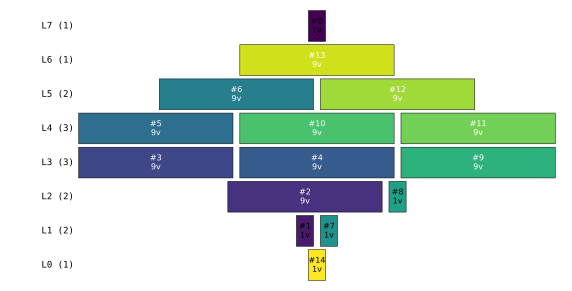

In [12]:
g_sel.plot_scc_decomp(figsize=(10, 5));

## When to use parallel elimination?


For `parallel_elimination=True` to help, it must be possible to decompose the graph into SCCs that can be distributed.

- Tall and thin:
  - All 1v tiles: Acyclic, no benefit from SCC composer. Leave default.
- Wide and square:
  - Stacked bands of large SCCs (Example 4): Cyclic but few parallel siblings per level. **Modest benefit**.
- Diamond:
  - All 1v tiles (Example 2): Acyclic forward chain. Leave default.
  - Wide multi-vertex rows in the middle (Example 3): Many parallel cyclic SCCs. **Great benefit**.
- A single huge tile covering everything:
  - Fully cyclic, no decomposition possible. Leave default; SCC composer cannot split.

## Live example

Lets try the ARG model with a larger sample size:

In [13]:
nr_samples = 7
indexer = StateIndexer(descendants=[
    Property('loc1', max_value=nr_samples),
    Property('loc2', max_value=nr_samples),
])
initial = [0] * indexer.state_length
initial[indexer.props_to_index(loc1=1, loc2=1)] = nr_samples

**No parallel elimination**:

In [14]:
g_arg = Graph(two_locus_arg, ipv=initial, indexer=indexer)
print(g_arg.vertices_length(), 'states')
g_arg.clear_from_cache(graph_cache=False) # keep graph cache

2999 states


{'graph_cache': 0, 'parameterized_reward_compute': 0}

In [15]:
%%time
# cache parameterized reward compute for graph
g_arg.update_weights([1, 0.7])
g_arg.prewarm_cache()

CPU times: user 64.9 ms, sys: 55.5 ms, total: 120 ms
Wall time: 121 ms


**Parallel elimination**:

In [16]:
g_arg = Graph(two_locus_arg, ipv=initial, indexer=indexer)
g_arg.update_weights([1, 0.7])
g_arg.clear_from_cache(graph_cache=False) # keep graph cache

cache.reset_scc_compose_stats()

In [17]:
g_arg = Graph(two_locus_arg, ipv=initial, indexer=indexer)
g_arg.update_weights([1, 0.7])

In [18]:
%%time
with configure(parallel_elimination=True):
    # cache parameterized reward compute for graph and its SCCs
    g_arg.prewarm_cache()

CPU times: user 165 ms, sys: 139 ms, total: 304 ms
Wall time: 131 ms


Hierarchical SCC stats:

In [19]:
stats = cache.scc_compose_stats()
print(stats)
print(f'total compose time: {int(stats['total_compose_ns'] / 1e+6):} ms')

{'cache_hits': 0, 'cache_misses': 0, 'compose_calls': 1, 'total_compose_ns': 128754000, 'cache_bypassed': 2}
total compose time: 128 ms


**Once cached**:

In [20]:
g_arg = Graph(two_locus_arg, ipv=initial, indexer=indexer)
g_arg.update_weights([1, 0.7])

In [21]:
%%time
g_arg.expectation()

CPU times: user 67.2 ms, sys: 59.8 ms, total: 127 ms
Wall time: 164 ms


2.1599920865206688